# Phase 3. Explore public realm lingering potential

## Green-space & playground extraction (shared setup)

This section downloads and filters the raw OSM public-realm geometry (playgrounds, parks and gardens) **once**, as shared input for the numbered indicator sections that follow.

A single filtering decision (see *Park and garden filtering decision* below) splits usable green spaces into **small parks** — which feed §3.1 *Immediate family public realm* — and **large parks** — which feed §3.2 *Destination leisure area*. All inspection layers, including the 400 m access buffers, are exported to `urban_amenities.gpkg` for QGIS.

No per-BGRI variables are created here: this step only produces and exports geometry. The subsection scores are built from these outputs in §3.1 and §3.2.

In [80]:
# Importing OSMnx, a Python library that enables the download, analysis, 
# and visualisation of geospatial data and street networks from 
# OpenStreetMap directly within Python.

import osmnx as ox

print(ox.__version__)

2.1.0


In [81]:
porto = ox.geocode_to_gdf("Porto, Portugal")

In [82]:
playgrounds = ox.features_from_polygon(
    porto.geometry.iloc[0],
    tags={"leisure": "playground"}
)

In [83]:
parks = ox.features_from_polygon(
    porto.geometry.iloc[0],
    tags={"leisure": ["park", "garden"]}
)

In [84]:
print(len(playgrounds))
print(len(parks))

playgrounds.head()
parks.head()

102
6852


geometry leisure  \
element id                                              
node    2377889036  POINT (-8.60267 41.14869)  garden   
        4466678185  POINT (-8.65822 41.16039)  garden   
        4643311478  POINT (-8.68839 41.16672)    park   
        4747717435  POINT (-8.64279 41.15273)  garden   
        4747717439  POINT (-8.64276 41.15292)  garden   

                                                name addr:city addr:street  \
element id                                                                   
node    2377889036                               NaN       NaN         NaN   
        4466678185                  Bosque das Faias       NaN         NaN   
        4643311478  Jardins da Avenida de Montevideu       NaN         NaN   
        4747717435              Núcleo das Palmeiras       NaN         NaN   
        4747717439             Clareira dos Plátanos       NaN         NaN   

                   alt_name contact:website internet_access official_name  \
element id                                                                  
node    2377889036      NaN             NaN             NaN           NaN   
        4466678185      NaN             NaN             NaN           NaN   
        4643311478      NaN             NaN             NaN           NaN   
        4747717435      NaN             NaN             NaN           NaN   
        4747717439      NaN             NaN             NaN           NaN   

                   opening_hours  ... note opening_date owner:website line  \
element id                        ...                                        
node    2377889036           NaN  ...  NaN          NaN           NaN  NaN   
        4466678185           NaN  ...  NaN          NaN           NaN  NaN   
        4643311478           NaN  ...  NaN          NaN           NaN  NaN   
        4747717435           NaN  ...  NaN          NaN           NaN  NaN   
        4747717439           NaN  ...  NaN          NaN           NaN  NaN   

                   contact:facebook contact:instagram contact:mobile  \
element id                                                             
node    2377889036              NaN               NaN            NaN   
        4466678185              NaN               NaN            NaN   
        4643311478              NaN               NaN            NaN   
        4747717435              NaN               NaN            NaN   
        4747717439              NaN               NaN            NaN   

                   contact:phone ownership reservation  
element id                                              
node    2377889036           NaN       NaN         NaN  
        4466678185           NaN       NaN         NaN  
        4643311478           NaN       NaN         NaN  
        4747717435           NaN       NaN         NaN  
        4747717439           NaN       NaN         NaN  

[5 rows x 84 columns]

In [85]:
# OSM data arrives in WGS84. Reproject to Portuguese metric coordinates before area or buffer calculations.
playgrounds = playgrounds.to_crs(3763)
parks = parks.to_crs(3763)

<Axes: >

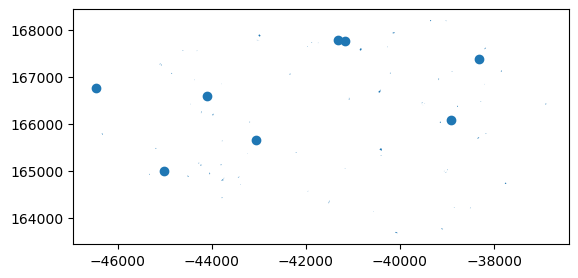

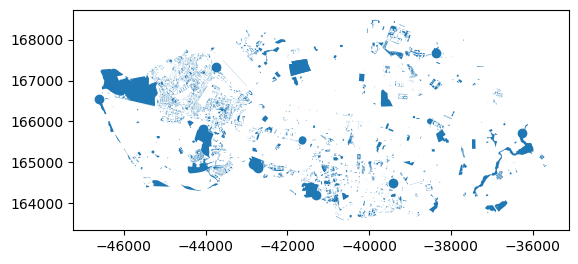

In [86]:
playgrounds.plot()
parks.plot()

In [87]:
# Exporting to QGIS:

playgrounds.to_file(
    "../Data/Processed/playgrounds_osm.gpkg",
    driver="GPKG"
)

parks.to_file(
    "../Data/Processed/parks_osm.gpkg",
    driver="GPKG"
)

### Park and garden filtering decision

Raw OSM parks/gardens include many tiny or private green fragments, such as backyards, landscaped fragments, and courtyard spaces. These should not be treated as meaningful public-realm amenities for the cafe location model.

A minimum area threshold is introduced to retain only green spaces with plausible public-realm and lingering potential. Large parks are still treated as destination green spaces, but accessibility is measured from their boundary using a 400m buffer, because someone is near a large park when they are near its edge or entrance rather than its geometric centre.

This decision is based on visual inspection in QGIS and the cafe concept's focus on local, repeat, everyday use.

In [88]:
MIN_GREEN_SPACE_M2 = 1000
LARGE_PARK_M2 = 20000
GREEN_SPACE_BUFFER_M = 400

POLYGON_GEOMETRY_TYPES = ["Polygon", "MultiPolygon"]

# Parks/gardens are polygon amenities in this model; points and lines are excluded.
raw_polygon_mask = parks.geometry.geom_type.isin(POLYGON_GEOMETRY_TYPES)
raw_polygon_count = int(raw_polygon_mask.sum())
parks_gardens_polygons = parks[raw_polygon_mask].copy()

# Exclude features that OSM clearly marks as private or inaccessible.
if "access" in parks_gardens_polygons.columns:
    access_values = (
        parks_gardens_polygons["access"]
        .astype("string")
        .str.lower()
        .str.strip()
    )
    parks_gardens_polygons = parks_gardens_polygons[
        ~access_values.isin(["private", "no"])
    ].copy()

parks_gardens_polygons["area_m2"] = parks_gardens_polygons.geometry.area

# Create a boolean flag: does this park/garden have a usable name?
parks_gardens_polygons["has_name"] = (
    parks_gardens_polygons["name"]
    .fillna("")
    .astype(str)
    .str.strip()
    .ne("")
)
# Keep only named and reasonably sized green spaces
usable_green_spaces = parks_gardens_polygons[
    (parks_gardens_polygons["has_name"]) &
    (parks_gardens_polygons["area_m2"] >= MIN_GREEN_SPACE_M2)
].copy()
# Split into small and large green spaces
small_parks = usable_green_spaces[
    usable_green_spaces["area_m2"] < LARGE_PARK_M2
].copy()

large_parks = usable_green_spaces[
    usable_green_spaces["area_m2"] >= LARGE_PARK_M2
].copy()

print(f"Raw polygon count: {raw_polygon_count}")
print(f"Usable green spaces count: {len(usable_green_spaces)}")
print(f"Small parks count: {len(small_parks)}")
print(f"Large parks count: {len(large_parks)}")
print("\nArea distribution for usable green spaces (m2):")
print(
    usable_green_spaces["area_m2"]
    .describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95])
    .round(1)
    .to_string()
)

Raw polygon count: 6837
Usable green spaces count: 93
Small parks count: 75
Large parks count: 18

Area distribution for usable green spaces (m2):
count        93.0
mean      26013.9
std       80634.4
min        1012.2
25%        2660.6
50%        5906.9
75%       15075.0
90%       42761.7
95%       96891.9
max      714945.9


In [89]:
from pathlib import Path

# Folder and output file
processed_dir = Path("../Data/Processed")
processed_dir.mkdir(parents=True, exist_ok=True)

amenities_path = processed_dir / "urban_amenities.gpkg"

# Rebuild this GeoPackage from scratch each time this notebook runs.
# This does NOT affect bgri_master.gpkg; original amenity geometries stay out of the master layer.
if amenities_path.exists():
    amenities_path.unlink()


def clean_for_qgis(gdf):
    """
    Keep only useful OSM columns and make the layer safe to export to GeoPackage.
    OSM often contains many irregular columns, so this avoids export problems
    and keeps QGIS tidy.
    """
    gdf = gdf.copy()
    gdf = gdf[gdf.geometry.notna()].copy()

    # Make invalid geometries valid where possible.
    try:
        gdf["geometry"] = gdf.geometry.make_valid()
    except Exception:
        pass

    # Preserve OSM index values such as element type / osmid.
    gdf = gdf.reset_index()

    # Add geometry type for visual inspection.
    gdf["geometry_type"] = gdf.geometry.geom_type

    if "area_m2" not in gdf.columns:
        gdf["area_m2"] = gdf.geometry.area

    useful_cols = [
        "element_type",
        "element",
        "osmid",
        "id",
        "name",
        "leisure",
        "amenity",
        "access",
        "shop",
        "tourism",
        "operator",
        "addr:street",
        "addr:housenumber",
        "geometry_type",
        "area_m2",
        "buffer_m",
    ]

    existing_cols = [c for c in useful_cols if c in gdf.columns]

    out = gdf[existing_cols + ["geometry"]].copy()

    # Convert lists/dicts into strings so GeoPackage export does not complain.
    for col in out.columns:
        if col != "geometry":
            out[col] = out[col].apply(
                lambda x: "; ".join(map(str, x)) if isinstance(x, (list, tuple, set))
                else str(x) if isinstance(x, dict)
                else x
            )

    return out


def write_layer(gdf, layer_name):
    """
    Write a GeoDataFrame as one layer inside urban_amenities.gpkg.
    """
    if gdf.empty:
        print(f"Skipped {layer_name}: empty layer")
        return

    gdf.to_file(
        amenities_path,
        layer=layer_name,
        driver="GPKG"
    )

    print(
        f"Wrote {layer_name}: {len(gdf)} features | "
        f"{gdf.geometry.geom_type.value_counts().to_dict()}"
    )


def make_buffer_layer(gdf, distance_m):
    """
    Create visual buffer polygons around the amenity geometries.
    These are for QGIS inspection, not yet the final analytical variables.
    """
    buffered = gdf.copy()
    buffered["buffer_m"] = distance_m
    buffered["geometry"] = buffered.geometry.buffer(distance_m)
    return buffered


# Clean layers for QGIS.
porto_boundary_qgis = clean_for_qgis(porto.to_crs(3763))
playgrounds_qgis = clean_for_qgis(playgrounds)
parks_qgis = clean_for_qgis(parks_gardens_polygons)
usable_green_spaces_qgis = clean_for_qgis(usable_green_spaces)
small_parks_qgis = clean_for_qgis(small_parks)
large_parks_qgis = clean_for_qgis(large_parks)

# Accessibility is measured from the actual polygon boundary/edge, not from centroids.
# BGRI centroids can later be joined against these buffers to create variables such as
# small_parks_access_400m and large_parks_access_400m.
playgrounds_400m_buffer = make_buffer_layer(playgrounds_qgis, GREEN_SPACE_BUFFER_M)
small_parks_400m_buffer = make_buffer_layer(small_parks_qgis, GREEN_SPACE_BUFFER_M)
large_parks_400m_buffer = make_buffer_layer(large_parks_qgis, GREEN_SPACE_BUFFER_M)

# Export all QGIS inspection layers into one GeoPackage.
write_layer(porto_boundary_qgis, "porto_boundary")
write_layer(playgrounds_qgis, "playgrounds_osm")
write_layer(parks_qgis, "parks_gardens_osm")
write_layer(usable_green_spaces_qgis, "usable_green_spaces")
write_layer(small_parks_qgis, "small_parks_gardens")
write_layer(large_parks_qgis, "large_parks_gardens")

write_layer(playgrounds_400m_buffer, "playgrounds_400m_buffer")
write_layer(small_parks_400m_buffer, "small_parks_400m_buffer")
write_layer(large_parks_400m_buffer, "large_parks_400m_buffer")

print(f"\nExport complete: {amenities_path}")

Wrote porto_boundary: 1 features | {'Polygon': 1}
Wrote playgrounds_osm: 102 features | {'Polygon': 94, 'Point': 8}
Wrote parks_gardens_osm: 6426 features | {'Polygon': 6419, 'MultiPolygon': 7}
Wrote usable_green_spaces: 93 features | {'Polygon': 87, 'MultiPolygon': 6}
Wrote small_parks_gardens: 75 features | {'Polygon': 71, 'MultiPolygon': 4}
Wrote large_parks_gardens: 18 features | {'Polygon': 16, 'MultiPolygon': 2}
Wrote playgrounds_400m_buffer: 102 features | {'Polygon': 102}
Wrote small_parks_400m_buffer: 75 features | {'Polygon': 75}
Wrote large_parks_400m_buffer: 18 features | {'Polygon': 18}

Export complete: ..\Data\Processed\urban_amenities.gpkg


## 3.1 Immediate family public realm (400m)

These are the "I leave school and drift somewhere pleasant" variables.

- small_parks_400m
- playgrounds_400m
- gardens_400m

Consumes `small_parks_400m_buffer` and `playgrounds_400m_buffer` from the shared extraction step above: join them to BGRI centroids to derive per-subsection access variables, then combine into a `family_public_realm_score` accumulated into `bgri_master.gpkg`.

## 3.2 Destination leisure area (400m)

This captures neighbourhood attractiveness and weekend routines.

- large_parks_access_400m

### Why entrances instead of whole-park buffers

The shared extraction step above buffers the *whole polygon boundary* of each large park (`large_parks_400m_buffer`). That's a reasonable first pass, but it overstates access in two ways:

1. A boundary buffer treats every metre of park edge as equally reachable, including edges that face a river, a walled-off backyard, or a road with no crossing.
2. It measures straight-line (Euclidean) distance, not the distance someone actually has to walk along streets and paths.

A destination-leisure indicator should instead be anchored on the park's actual **entrances** — the points where a pedestrian can physically enter — and measure how far someone can walk from each entrance **along the real street network**. The rest of this section rebuilds the geometry behind `large_parks_access_400m` on that basis:

1. Combine the manually reviewed entrance points (`entrances_review` + `entrances_kept`) into one `entrances` layer.
2. Build a simple 400m Euclidean buffer from those entrances, as a baseline for comparison only.
3. Load Porto's walkable OSM street network (motorways and other non-pedestrian roads excluded).
4. For each entrance, compute a 400m walking-distance **network service area** — reachable on foot within 400m of street/path travel, not straight-line distance.
5. Validate visually and numerically against both Euclidean baselines.

The entrance points are a manually curated input (digitised and reviewed directly in QGIS, see `Data/Processed/park_entrances_draft.gpkg`) — this notebook treats them as read-only and never edits their geometry in code. Only the buffering/network analysis downstream is generated here, so the pipeline from entrances → service areas is fully reproducible by rerunning this notebook.

Aggregating this new geometry into `bgri_master.gpkg` as `large_parks_access_400m` is deferred until §3.2.6 *Validation* below has been reviewed — the geometry work here is the prerequisite, not yet the aggregation.

In [ ]:
import geopandas as gpd
import pandas as pd
import numpy as np
import networkx as nx  # ships as an OSMnx dependency, no extra install needed
import matplotlib.pyplot as plt
import contextily as ctx
from shapely.geometry import Point, LineString
from shapely.ops import unary_union, substring

SERVICE_AREA_DISTANCE_M = 400
NETWORK_CORRIDOR_HALF_WIDTH_M = 12.5  # turns a reachable street centreline into a walkable-corridor polygon

### 3.2.1 Park entrances (input layer)

`entrances_review` and `entrances_kept` are manually reviewed candidate park entrances — OSM footpath × park-boundary crossings, checked point-by-point in QGIS against ground truth for parks such as Covelo, Queimódromo and Palácio de Cristal. They live in `Data/Processed/park_entrances_draft.gpkg`.

This notebook treats them as a **fixed, read-only input**: entrance geometry is never edited in code, only combined and used as the anchor for the buffering/network analysis below. `entrances_excluded` (candidates rejected during review) is intentionally left out of the combined layer.

In [91]:
entrances_path = Path("../Data/Processed/park_entrances_draft.gpkg")

entrances_review = gpd.read_file(entrances_path, layer="entrances_review")
entrances_kept = gpd.read_file(entrances_path, layer="entrances_kept")

entrances_review["source"] = "entrances_review"
entrances_kept["source"] = "entrances_kept"

park_entrances = pd.concat([entrances_kept, entrances_review], ignore_index=True)
park_entrances = gpd.GeoDataFrame(park_entrances, geometry="geometry", crs=entrances_kept.crs)

# Both source layers are already EPSG:3763; guard against a future re-review being saved in another CRS.
if park_entrances.crs.to_epsg() != 3763:
    park_entrances = park_entrances.to_crs(3763)

park_entrances = park_entrances.reset_index(drop=True)
park_entrances["entrance_id"] = park_entrances.index + 1

print(
    f"Combined park entrances: {len(park_entrances)} "
    f"({(park_entrances['source'] == 'entrances_kept').sum()} kept, "
    f"{(park_entrances['source'] == 'entrances_review').sum()} review)"
)

park_entrances.to_file(entrances_path, layer="entrances", driver="GPKG")
park_entrances.head()

Combined park entrances: 133 (100 kept, 33 review)


,park,geometry,source,entrance_id
0,Jardim do Passeio Alegre,POINT (-44928.556 164404.871),entrances_kept,1
1,Jardim do Passeio Alegre,POINT (-45286.045 164420.028),entrances_kept,2
2,Jardim do Passeio Alegre,POINT (-44926.361 164430.831),entrances_kept,3
3,Jardim do Passeio Alegre,POINT (-45309.427 164501.887),entrances_kept,4
4,Jardim do Passeio Alegre,POINT (-45296.758 164557.224),entrances_kept,5


### 3.2.2 Euclidean baseline buffer

A plain 400m circular buffer around each entrance — kept only as a straight-line baseline to compare against the network-based service area below. It is **not** the final accessibility measure.

In [92]:
entrances_400m_buffer_euclidean = park_entrances.copy()
entrances_400m_buffer_euclidean["geometry"] = park_entrances.geometry.buffer(SERVICE_AREA_DISTANCE_M)
entrances_400m_buffer_euclidean["buffer_m"] = SERVICE_AREA_DISTANCE_M

entrances_400m_buffer_euclidean.to_file(
    entrances_path, layer="entrances_400m_buffer_euclidean", driver="GPKG"
)

print(f"Euclidean buffers created: {len(entrances_400m_buffer_euclidean)}")

Euclidean buffers created: 133


### 3.2.3 Walkable pedestrian network

Loads Porto's OSM pedestrian network with `network_type="walk"`, which already excludes motorways, trunk roads and other non-walkable classes via OSMnx's built-in filter. A defensive check removes any motorway/trunk edge that slipped through regardless, since correctness matters more than convenience here.

The network downloads in WGS84 (OSMnx's native CRS) and is reprojected to EPSG:3763 so the service-area buffering below works in metres, per this project's spatial conventions.

In [93]:
NON_WALKABLE_HIGHWAY_TAGS = {"motorway", "motorway_link", "trunk", "trunk_link"}

walk_graph = ox.graph_from_polygon(
    porto.geometry.iloc[0],
    network_type="walk",
    simplify=True,
)

def _highway_tags(value):
    if isinstance(value, (list, tuple, set)):
        return set(value)
    return {value}

non_walkable_edges = [
    (u, v, k)
    for u, v, k, data in walk_graph.edges(keys=True, data=True)
    if _highway_tags(data.get("highway")) & NON_WALKABLE_HIGHWAY_TAGS
]
walk_graph.remove_edges_from(non_walkable_edges)

print(f"Walk network: {walk_graph.number_of_nodes()} nodes, {walk_graph.number_of_edges()} edges")
print(f"Non-walkable edges removed by the defensive check: {len(non_walkable_edges)}")

# Reproject to Portuguese metric coordinates so distances/buffers below are in metres.
walk_graph_proj = ox.project_graph(walk_graph, to_crs=3763)

# Pedestrians aren't constrained by vehicle one-way restrictions, so treat the network
# as undirected for reachability purposes.
walk_graph_undirected = walk_graph_proj.to_undirected()

Walk network: 23149 nodes, 59850 edges
Non-walkable edges removed by the defensive check: 18


### 3.2.4 Network-based service areas (400m walking distance)

For each entrance: connect it to the surrounding pedestrian network, compute single-source shortest-path distances (`networkx`, weighted by edge `length`), and paint every street segment reachable within 400m of cumulative walking distance as a corridor polygon (centreline buffered by a small half-width, dissolved). The result follows streets instead of drawing a Euclidean circle. Partially reachable segments are clipped at the remaining budget, so a long boundary road shows exactly how far along it 400m gets you.

This is the standard "network buffer" approximation to a true isochrone — good enough for comparing relative reach between entrances without needing a dedicated service-area/Network Analyst tool. Entrances with no reachable street geometry within range fall back to a small buffer around the entrance itself.

Getting this to produce *correct* results took several graph corrections, each found by validating against ground truth (Parque do Covelo, then an audit of all 133 entrances). They are all applied in the cell below, in order:

1. **Fill missing edge geometry.** OSMnx's simplified graphs only attach `geometry` to curved edges; straight edges carry none, which made straight streets invisible to every geometry-dependent step below.
2. **Exclude interior park paths.** `network_type="walk"` includes a park's own trail network; without exclusion, Covelo's entrances spent the entire 400m budget looping inside the park instead of reaching the neighbourhood.
3. **Consolidate nodes at shared junctions — seed-bounded, not transitive.** OSM often digitises a footpath junction and the street it meets as separate points a few metres apart (12.6m at one Covelo entrance ⇒ an 870m detour). Nodes within 15m of a cluster seed merge; bounding by the seed caps cluster diameter, because transitive chaining produced ~200m "wormhole" clusters with free internal travel that leaked Covelo's walkshed 1.4km north into Asprela.
4. **Connect each entrance to every nearby street edge, non-destructively, with an orientation check.** Some entrance connectors were never topologically joined to the road they sit beside (Rua do Bolama: 8.5m away, 1,200m+ by graph). The entrance gets virtual edges to both endpoints of each street edge within 30m (perpendicular + along-edge distance). Two hard-won details: the connection must not split the street edge (a destructive split silently broke every subsequent entrance sharing the same street — five at Parque Oriental), and the endpoint-to-geometry orientation must be checked explicitly, because networkx yields `(u, v)` in arbitrary order relative to the stored geometry — unchecked, ~half the connectors attached the entrance to the far endpoint with the near distance.
5. **Paint partially reachable edges.** An induced-subgraph approach (`ego_graph`) drops any edge whose far endpoint is beyond budget, hiding the genuinely walkable first stretch of long junction-free roads.

**Known residual limitations** (audited, judged acceptable): a few entrances legitimately can't reach some nearby-looking streets within 400m — walled estates (Serralves), escarpments (Palácio de Cristal), river-valley detours (Parque Oriental / Rio Tinto), and one Av. da Boavista stub at Parque da Cidade with no pedestrian crossing mapped in OSM. These reflect real barriers or upstream OSM gaps, not routing errors.

In [ ]:
# OSMnx's simplified graphs only attach a `geometry` attribute to curved (multi-vertex)
# edges; perfectly straight edges carry none. Everything below relies on edge geometry
# (interior-park exclusion, street-edge snapping, and painting the corridor polygons), so
# fill the gaps with a straight line between the edge's own end nodes.
for u, v, k, data in walk_graph_undirected.edges(keys=True, data=True):
    if data.get("geometry") is None:
        data["geometry"] = LineString([
            (walk_graph_undirected.nodes[u]["x"], walk_graph_undirected.nodes[u]["y"]),
            (walk_graph_undirected.nodes[v]["x"], walk_graph_undirected.nodes[v]["y"]),
        ])

# Exclude a park's own interior footpath network from the routing graph used here --
# see the note above. Edges lying entirely within a large park are dropped; edges that
# cross the boundary (an entrance's connector to the street) are kept.
large_parks_union = unary_union(large_parks.geometry)

interior_park_edges = [
    (u, v, k)
    for u, v, k, data in walk_graph_undirected.edges(keys=True, data=True)
    if data["geometry"].within(large_parks_union)
]

walk_graph_for_entrances = walk_graph_undirected.copy()
walk_graph_for_entrances.remove_edges_from(interior_park_edges)

# Nodes left with no edges at all (pure interior dead-ends, e.g. a park's own trailhead)
# must also be dropped -- otherwise an entrance could still snap to one of these stranded
# nodes and end up with zero reachable street network.
walk_graph_for_entrances.remove_nodes_from(list(nx.isolates(walk_graph_for_entrances)))

print(f"Interior park-path edges excluded from entrance routing: {len(interior_park_edges)}")

# Consolidate nodes that sit within a small tolerance of a shared junction -- see the
# note above. OSM sometimes digitises a footpath/steps junction and the street it meets
# as two separate, unconnected points a few metres apart, forcing a large unrealistic
# detour between what is really the same junction.
#
# The clustering is SEED-BOUNDED, not transitive: a node only joins a cluster if it lies
# within tolerance of the cluster's first (seed) node, capping cluster diameter at twice
# the tolerance. A transitive union ("A near B, B near C => A,B,C merge") lets chains of
# closely spaced nodes collapse into clusters up to ~200m across, and travel within a
# merged cluster costs zero -- these wormholes let Covelo's walksheds leak 1.4km north
# into the Asprela area before this was bounded.
NODE_CONSOLIDATION_TOLERANCE_M = 15

node_xy = {n: (walk_graph_for_entrances.nodes[n]["x"], walk_graph_for_entrances.nodes[n]["y"])
           for n in walk_graph_for_entrances.nodes}

cluster_of = {}
seed_positions = {}
seed_grid = {}
for n in sorted(walk_graph_for_entrances.nodes):  # sorted => deterministic clustering
    x, y = node_xy[n]
    cx, cy = int(x // NODE_CONSOLIDATION_TOLERANCE_M), int(y // NODE_CONSOLIDATION_TOLERANCE_M)
    best_seed, best_dist = None, None
    for dx in (-1, 0, 1):
        for dy in (-1, 0, 1):
            for s in seed_grid.get((cx + dx, cy + dy), []):
                sx, sy = seed_positions[s]
                d = np.hypot(x - sx, y - sy)
                if d <= NODE_CONSOLIDATION_TOLERANCE_M and (best_dist is None or d < best_dist):
                    best_dist, best_seed = d, s
    if best_seed is not None:
        cluster_of[n] = best_seed
    else:
        cluster_of[n] = n
        seed_positions[n] = (x, y)
        seed_grid.setdefault((cx, cy), []).append(n)

walk_graph_consolidated = nx.Graph()
for u, v, data in walk_graph_for_entrances.edges(data=True):
    ru, rv = cluster_of[u], cluster_of[v]
    if ru == rv:
        continue
    length = data["length"]
    if walk_graph_consolidated.has_edge(ru, rv):
        if length < walk_graph_consolidated[ru][rv]["length"]:
            walk_graph_consolidated[ru][rv].update(
                length=length, geometry=data["geometry"], highway=data.get("highway"))
    else:
        walk_graph_consolidated.add_edge(ru, rv, length=length, geometry=data["geometry"], highway=data.get("highway"))

for n in walk_graph_consolidated.nodes:
    x, y = node_xy[n]
    walk_graph_consolidated.nodes[n]["x"] = x
    walk_graph_consolidated.nodes[n]["y"] = y

print(f"Consolidated graph: {walk_graph_consolidated.number_of_nodes()} nodes "
      f"(from {walk_graph_for_entrances.number_of_nodes()}), {walk_graph_consolidated.number_of_edges()} edges")

walk_graph_for_entrances = walk_graph_consolidated

# Connect each entrance to every real street EDGE within tolerance (not just the nearest
# graph node) -- see the note above. Some entrances' own connector path was never
# topologically joined to the road it sits beside at all, which node consolidation alone
# can't fix. The connection is made WITHOUT splitting the street edge: the entrance gets
# a virtual edge to BOTH endpoints of each nearby street edge, with length = perpendicular
# distance to the edge + along-edge distance to that endpoint. Non-destructive, so any
# number of entrances can connect to the same street edge.
ENTRANCE_EDGE_SNAP_TOLERANCE_M = 30
STREET_HIGHWAY_SUBSTRINGS = ("residential", "living_street", "secondary", "tertiary", "unclassified", "primary")
MIN_EDGE_LENGTH_M = 0.01  # guards against zero-length connectors at an entrance sitting exactly on a node

street_edges_gdf = gpd.GeoDataFrame(
    [
        {"u": u, "v": v, "geometry": data["geometry"], "length": data["length"]}
        for u, v, data in walk_graph_for_entrances.edges(data=True)
        if any(t in str(data.get("highway", "")) for t in STREET_HIGHWAY_SUBSTRINGS)
    ],
    crs=park_entrances.crs,
)
street_sindex = street_edges_gdf.sindex

# The consolidated graph is a plain networkx.Graph (not an OSMnx graph), so
# ox.distance.nearest_nodes can't be used here -- it requires the graph-level `crs`
# attribute OSMnx sets when it builds a graph itself. A direct numpy nearest-node
# lookup over the node coordinates does the same job.
graph_nodes = list(walk_graph_for_entrances.nodes)
graph_nodes_xy = np.array([node_xy[n] for n in graph_nodes])

walk_graph_routable = walk_graph_for_entrances.copy()
entrance_start_nodes = {}
connector_count = 0

for _, entrance in park_entrances.iterrows():
    pt = entrance.geometry
    start_node = f"entrance_{entrance['entrance_id']}"
    walk_graph_routable.add_node(start_node, x=pt.x, y=pt.y)

    # Baseline connection: nearest graph node, straight-line distance.
    node_dists = np.hypot(graph_nodes_xy[:, 0] - pt.x, graph_nodes_xy[:, 1] - pt.y)
    nearest_node = graph_nodes[int(node_dists.argmin())]
    walk_graph_routable.add_edge(start_node, nearest_node, length=max(float(node_dists.min()), MIN_EDGE_LENGTH_M))

    # Street-edge connections: both endpoints of every street edge within tolerance.
    for ci in street_sindex.query(pt.buffer(ENTRANCE_EDGE_SNAP_TOLERANCE_M)):
        row = street_edges_gdf.iloc[int(ci)]
        geom = row.geometry
        perp_dist = geom.distance(pt)
        if perp_dist > ENTRANCE_EDGE_SNAP_TOLERANCE_M:
            continue
        proj_dist = min(max(geom.project(pt), 0.0), geom.length)
        # The graph's length attribute can differ slightly from raw geometry length
        # (e.g. after consolidation); scale along-edge distances to stay consistent.
        length_ratio = row["length"] / geom.length if geom.length > 0 else 1.0

        # ORIENTATION CHECK: networkx yields (u, v) in arbitrary order relative to the
        # stored geometry, so determine which endpoint actually sits at the geometry's
        # start before assigning along-edge distances. Without this, ~half the connectors
        # attach the entrance to the FAR endpoint with the NEAR distance -- one such swap
        # on an 895m road out of Covelo teleported its walkshed 1.4km up to Asprela.
        gstart, gend = geom.coords[0], geom.coords[-1]
        ux, uy = node_xy[row["u"]]
        u_at_start = np.hypot(ux - gstart[0], uy - gstart[1]) <= np.hypot(ux - gend[0], uy - gend[1])
        along_u = proj_dist * length_ratio if u_at_start else (geom.length - proj_dist) * length_ratio
        along_v = (geom.length - proj_dist) * length_ratio if u_at_start else proj_dist * length_ratio

        for endpoint, along_dist in ((row["u"], along_u), (row["v"], along_v)):
            connector_length = max(perp_dist + along_dist, MIN_EDGE_LENGTH_M)
            if walk_graph_routable.has_edge(start_node, endpoint):
                if connector_length < walk_graph_routable[start_node][endpoint]["length"]:
                    walk_graph_routable[start_node][endpoint]["length"] = connector_length
            else:
                walk_graph_routable.add_edge(start_node, endpoint, length=connector_length)
                connector_count += 1

    entrance_start_nodes[entrance["entrance_id"]] = start_node

print(f"Entrance street-edge connectors added: {connector_count}")

# Build each entrance's service area from single-source shortest-path distances rather
# than ego_graph: ego_graph only keeps an edge when BOTH endpoints are within budget, so
# a long boundary road with no intermediate junctions would be dropped entirely even
# though its first few hundred metres are genuinely walkable. Fully reachable edges are
# painted whole; partially reachable ones are clipped at the remaining walking budget.
service_area_rows = []
for _, entrance in park_entrances.iterrows():
    entrance_pt = entrance.geometry
    start_node = entrance_start_nodes[entrance["entrance_id"]]
    reach = nx.single_source_dijkstra_path_length(
        walk_graph_routable, start_node, cutoff=SERVICE_AREA_DISTANCE_M, weight="length"
    )

    reachable_pieces = []
    seen_pairs = set()
    for n in reach:
        for neighbour in walk_graph_routable.neighbors(n):
            pair = tuple(sorted((str(n), str(neighbour))))
            if pair in seen_pairs:
                continue
            seen_pairs.add(pair)
            data = walk_graph_routable[n][neighbour]
            geom = data.get("geometry")
            if geom is None:  # entrance/street connectors carry no geometry
                continue
            dist_n, dist_nb = reach.get(n), reach.get(neighbour)
            if dist_n is not None and dist_nb is not None:
                reachable_pieces.append(geom)
            else:
                # Partially reachable: clip at the remaining budget from the reached side.
                reached_node, reached_dist = (n, dist_n) if dist_n is not None else (neighbour, dist_nb)
                remaining = SERVICE_AREA_DISTANCE_M - reached_dist
                if remaining <= 0:
                    continue
                fraction = min(remaining / data["length"], 1.0) if data["length"] > 0 else 1.0
                gstart, gend = geom.coords[0], geom.coords[-1]
                rx, ry = node_xy[reached_node]
                at_start = np.hypot(rx - gstart[0], ry - gstart[1]) <= np.hypot(rx - gend[0], ry - gend[1])
                clip_length = fraction * geom.length
                piece = substring(geom, 0, clip_length) if at_start else substring(geom, geom.length - clip_length, geom.length)
                if piece is not None and not piece.is_empty:
                    reachable_pieces.append(piece)

    if reachable_pieces:
        reachable_geometry = unary_union([g.buffer(NETWORK_CORRIDOR_HALF_WIDTH_M) for g in reachable_pieces])
    else:
        # No reachable street geometry within range: fall back to a small buffer around
        # the entrance itself so it still gets a service area.
        reachable_geometry = Point(entrance_pt.x, entrance_pt.y).buffer(NETWORK_CORRIDOR_HALF_WIDTH_M)

    service_area_rows.append({
        "entrance_id": entrance["entrance_id"],
        "park": entrance.get("park"),
        "source": entrance["source"],
        "distance_m": SERVICE_AREA_DISTANCE_M,
        "geometry": reachable_geometry,
    })

entrances_400m_service_area_network = gpd.GeoDataFrame(service_area_rows, geometry="geometry", crs=3763)

entrances_400m_service_area_network.to_file(
    entrances_path, layer="entrances_400m_service_area_network", driver="GPKG"
)

print(f"Network service areas created: {len(entrances_400m_service_area_network)}")

### 3.2.5 Export the walkable network for QGIS inspection

The pedestrian network itself is reproducible OSM-derived geometry, like the other amenity layers in the shared setup above, so it is exported into `urban_amenities.gpkg` (rebuilt from scratch each run) rather than mixed into the entrance-specific file.

In [95]:
walk_edges_qgis = ox.graph_to_gdfs(walk_graph_proj, nodes=False, edges=True).reset_index()
walk_edges_qgis["highway"] = walk_edges_qgis["highway"].apply(
    lambda x: "; ".join(map(str, x)) if isinstance(x, (list, tuple, set)) else x
)
walk_edges_qgis = walk_edges_qgis[["u", "v", "key", "highway", "length", "geometry"]]

write_layer(walk_edges_qgis, "porto_walk_network")

Wrote porto_walk_network: 59850 features | {'LineString': 59850}


### 3.2.6 Validation

Sanity-check the new geometry before it replaces `large_parks_400m_buffer` as the source for `large_parks_access_400m`: map the entrances and both service-area methods together, then compare areas against each other and against the existing whole-park Euclidean buffer.

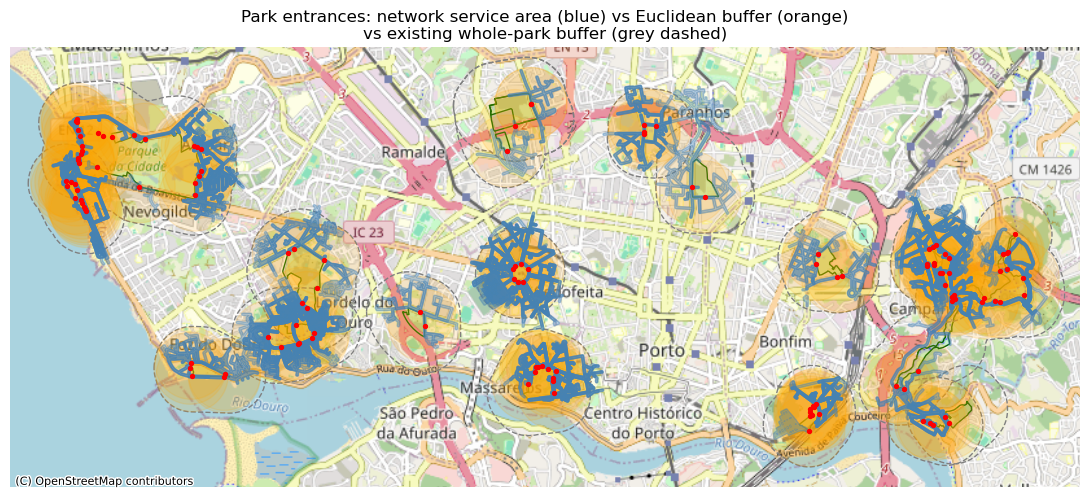

In [96]:
entrances_web = park_entrances.to_crs(epsg=3857)
euclidean_web = entrances_400m_buffer_euclidean.to_crs(epsg=3857)
network_web = entrances_400m_service_area_network.to_crs(epsg=3857)
large_parks_buffer_web = large_parks_400m_buffer.to_crs(epsg=3857)
large_parks_web = large_parks.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(11, 11))

large_parks_web.plot(ax=ax, color="none", edgecolor="darkgreen", linewidth=1)
large_parks_buffer_web.plot(ax=ax, color="none", edgecolor="grey", linestyle="--", linewidth=1)
euclidean_web.plot(ax=ax, color="orange", alpha=0.15, edgecolor="orange")
network_web.plot(ax=ax, color="steelblue", alpha=0.4, edgecolor="steelblue")
entrances_web.plot(ax=ax, color="red", markersize=8, zorder=5)

# Zoom to the entrances rather than the whole city, so the comparison is legible.
minx, miny, maxx, maxy = euclidean_web.total_bounds
margin = 300
ax.set_xlim(minx - margin, maxx + margin)
ax.set_ylim(miny - margin, maxy + margin)

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_title(
    "Park entrances: network service area (blue) vs Euclidean buffer (orange)\n"
    "vs existing whole-park buffer (grey dashed)"
)
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [97]:
comparison = entrances_400m_service_area_network[["entrance_id", "park", "source"]].copy()
comparison["network_area_m2"] = entrances_400m_service_area_network.geometry.area.values
comparison["euclidean_area_m2"] = entrances_400m_buffer_euclidean.geometry.area.values
comparison["network_share_of_euclidean"] = (
    comparison["network_area_m2"] / comparison["euclidean_area_m2"]
)

print(
    f"Network service areas are on average "
    f"{comparison['network_share_of_euclidean'].mean():.0%} of the size of the "
    f"equivalent Euclidean circle — the street network constrains reach, as expected."
)
comparison.sort_values("network_share_of_euclidean").head(10)

Network service areas are on average 24% of the size of the equivalent Euclidean circle — the street network constrains reach, as expected.


,entrance_id,park,source,network_area_m2,euclidean_area_m2,network_share_of_euclidean
73,74,Parque da Cidade,entrances_kept,5630.106999,501847.758487,0.011219
75,76,Parque da Cidade,entrances_kept,5908.981610,501847.758487,0.011774
76,77,Parque da Cidade,entrances_kept,11380.206164,501847.758487,0.022677
128,129,Parque da Cidade,entrances_review,15803.152103,501847.758487,0.031490
113,114,Jardins do Palácio de Cristal,entrances_review,16457.969597,501847.758487,0.032795
129,130,Parque da Cidade,entrances_review,16853.180136,501847.758487,0.033582
107,108,Parque Oriental da cidade do Porto,entrances_review,19964.674640,501847.758487,0.039782
100,101,Quinta da Prelada,entrances_review,20433.124109,501847.758487,0.040716
130,131,Parque da Cidade,entrances_review,20864.602494,501847.758487,0.041576
114,115,Jardim da Avenida de Montevideu,entrances_review,25098.103452,501847.758487,0.050011


## 3.3 Accessibility

For this customer profile, parking and metro matters more than bus. 


- Metro variable: distance to nearest metro.

- Car parking

Finding reliable parking datasets is often surprisingly hard.

Potential proxies:

surface parking lots within 400m
average street width
residential density inverse
parking garages within 600m

I need to think the best way to see this, because although it is hard data to find, it is potentially the make-or-break factor in a city where most of the upper middle class relies mainly on the car to circulate (except for foreign citizens).

## 3.4 Cultural and intellectual amenities (600m)

Variables:
- libraries_600m
- bookshops_600m
- cultural_venues_600m
- coworking_spaces_600m (target customer includes freelancers and remote workers)

These variables measure neighbourhoods where lingering, reading and cultural consumption already exist.